<!-- Cell purpose: Introduce the embryonated control analysis notebook. -->

# Control Analysis (Embryonated / Larvated Eggs)

This notebook analyzes pooled embryonated control datasets from `master_csv/02_master_embryonated.csv`.

Controls pooled (`control == 1`):
- `400-SHG-40mW-control`
- `800-control-330mW`
- `400-SHG-20mW-control`

Rules used:
- Main timing readout: `dt_motion_stop_h = t_motion_stop_h - t_start_h`
- If `t_motion_stop_h = NA` and `death_mode = NA`: larva continued motion until end of footage
- `flags = death_after_hatch`: larva hatched spontaneously and died after hatch (`death_mode` expected `uncertain`)
- In-egg stop cohort excludes `death_after_hatch`
- Max footage time: `700 h`


In [1]:
# Import libraries and configure notebook settings

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/02_master_embryonated.csv"
CONTROL_LABELS = [
    "400-SHG-40mW-control",
    "800-control-330mW",
    "400-SHG-20mW-control",
]
MAX_FOOTAGE_H = 700

DEATH_MODE_DISPLAY = {
    "apoptotic_like": "Vacuolated (apoptosis-like)",
    "necrotic_like": "Lytic (necrosis-like)",
    "uncertain": "Indeterminate/hatched",
    "uncertein": "Indeterminate/hatched",
}
TERMINAL_PHENOTYPE_LABEL = "Terminal phenotype"

PLOTS_DIR = Path("400nm/controls/plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("400nm/controls/tables/")
TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"", "na", "none"}:
        return np.nan
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan


def normalize_flags(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    if raw == "" or raw.lower() in {"na", "none"}:
        return np.nan

    parts = [to_snake_or_nan(part) for part in raw.split(";")]
    parts = [p for p in parts if pd.notna(p)]
    if not parts:
        return np.nan
    return ";".join(parts)


def has_flag(series: pd.Series, token: str) -> pd.Series:
    token_norm = to_snake_or_nan(token)
    if pd.isna(token_norm):
        return pd.Series(False, index=series.index)
    pattern = rf"(^|;){re.escape(token_norm)}($|;)"
    return series.fillna("").str.contains(pattern, regex=True)


def pct(n: int, d: int) -> float:
    return (100.0 * n / d) if d else np.nan


def median_iqr(series: pd.Series):
    vals = series.dropna().astype(float)
    if vals.empty:
        return np.nan, np.nan, np.nan
    return float(vals.median()), float(vals.quantile(0.25)), float(vals.quantile(0.75))


In [3]:
# Load and clean source table

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

required_cols = [
    "egg_uid",
    "exp_label",
    "start_date",
    "control",
    "t_start_h",
    "t_motion_stop_h",
    "death_mode",
    "flags",
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "death_mode"]:
    if col in df.columns:
        df[col] = df[col].map(to_snake_or_nan)

if "death_mode" in df.columns:
    df["death_mode"] = df["death_mode"].replace({"uncertein": "uncertain"})

if "flags" in df.columns:
    df["flags"] = df["flags"].map(normalize_flags)

df["exp_label_norm"] = df["exp_label"].map(to_snake_or_nan)

for col in ["control", "wl_nm", "power_mW", "irradiance_mW_cm2", "exposure_s", "fluence_J_cm2", "t_start_h", "t_motion_stop_h"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["dt_motion_stop_h"] = df["t_motion_stop_h"] - df["t_start_h"]

control_label_norm = {to_snake_or_nan(x) for x in CONTROL_LABELS}
ctrl_df = df[(df["control"] == 1) & (df["exp_label_norm"].isin(control_label_norm))].copy()

print(f"Loaded: {csv_file}")
print(f"Rows in master table: {len(df)}")
print(f"Rows where control == 1 (all labels): {(df['control'] == 1).sum()}")
print(f"Rows in pooled named controls: {len(ctrl_df)}")

ctrl_preview_df = ctrl_df[["egg_uid", "exp_label", "start_date", "t_start_h", "t_motion_stop_h", "dt_motion_stop_h", "death_mode", "flags"]].copy()
ctrl_preview_df[TERMINAL_PHENOTYPE_LABEL] = (
    ctrl_preview_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(ctrl_preview_df["death_mode"])
)
display(ctrl_preview_df.drop(columns=["death_mode"]).head())


Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/02_master_embryonated.csv
Rows in master table: 811
Rows where control == 1 (all labels): 97
Rows in pooled named controls: 97


,egg_uid,exp_label,start_date,t_start_h,t_motion_stop_h,dt_motion_stop_h,flags,Terminal phenotype
114,115,400-SHG-40mW-control,2024-07-23,41.5,NaN,NaN,NaN,NaN
115,116,400-SHG-40mW-control,2024-07-23,41.5,NaN,NaN,NaN,NaN
116,117,400-SHG-40mW-control,2024-07-23,41.5,NaN,NaN,NaN,NaN
117,118,400-SHG-40mW-control,2024-07-23,41.5,NaN,NaN,NaN,NaN
118,119,400-SHG-40mW-control,2024-07-23,41.5,NaN,NaN,NaN,NaN


In [4]:
# QC check: controls, death_modes, flags, timing completeness

n_ctrl_all = int((df["control"] == 1).sum())
n_ctrl = int(len(ctrl_df))

qc_overview = pd.DataFrame(
    [
        {"metric": "rows_total_in_master", "value": int(len(df))},
        {"metric": "rows_with_control_eq_1", "value": n_ctrl_all},
        {"metric": "rows_in_pooled_named_controls", "value": n_ctrl},
        {"metric": "rows_control_eq_1_not_in_named_controls", "value": int(n_ctrl_all - n_ctrl)},
        {
            "metric": "rows_with_t_motion_stop_h_gt_700_in_pooled_controls",
            "value": int((ctrl_df["t_motion_stop_h"] > MAX_FOOTAGE_H).sum()),
        },
    ]
)
display(qc_overview)

qc_by_control_label = (
    ctrl_df.groupby(["exp_label", "start_date"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["exp_label", "start_date"])
)
display(qc_by_control_label)

qc_death_mode = (
    ctrl_df["death_mode"]
    .fillna("na")
    .replace(DEATH_MODE_DISPLAY)
    .value_counts(dropna=False)
    .rename_axis(TERMINAL_PHENOTYPE_LABEL)
    .reset_index(name="n")
)
qc_death_mode["pct"] = qc_death_mode["n"].map(lambda x: round(pct(int(x), n_ctrl), 1))
display(qc_death_mode)

qc_flags = (
    ctrl_df["flags"].fillna("na").value_counts(dropna=False)
    .rename_axis("flags")
    .reset_index(name="n")
)
qc_flags["pct"] = qc_flags["n"].map(lambda x: round(pct(int(x), n_ctrl), 1))
display(qc_flags)

qc_flags_vs_mode = pd.crosstab(
    ctrl_df["flags"].fillna("na"),
    ctrl_df["death_mode"].fillna("na"),
    dropna=False,
)
qc_flags_vs_mode = qc_flags_vs_mode.rename(columns=DEATH_MODE_DISPLAY)
qc_flags_vs_mode.columns.name = TERMINAL_PHENOTYPE_LABEL
display(qc_flags_vs_mode)

qc_timing_state = (
    ctrl_df.assign(
        t_motion_stop_state=np.where(ctrl_df["t_motion_stop_h"].isna(), "na", "present"),
        death_mode_state=np.where(ctrl_df["death_mode"].isna(), "na", "present"),
    )
    .groupby(["t_motion_stop_state", "death_mode_state"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
)
display(qc_timing_state)

n_terminal_twitching = int(has_flag(ctrl_df["flags"], "terminal_twitching").sum())
terminal_twitching_qc = pd.DataFrame(
    [
        {
            "phenotype": "terminal_twitching",
            "n": n_terminal_twitching,
            "pct": round(pct(n_terminal_twitching, n_ctrl), 1),
        }
    ]
)
display(terminal_twitching_qc)

qc_overview.to_csv(TABLES_DIR / "controls_qc_overview.csv", index=False)
qc_by_control_label.to_csv(TABLES_DIR / "controls_qc_counts_by_label_date.csv", index=False)
qc_death_mode.to_csv(TABLES_DIR / "controls_qc_death_mode_counts.csv", index=False)
qc_flags.to_csv(TABLES_DIR / "controls_qc_flag_counts.csv", index=False)
qc_flags_vs_mode.to_csv(TABLES_DIR / "controls_qc_flags_vs_death_mode.csv")
qc_timing_state.to_csv(TABLES_DIR / "controls_qc_timing_state_counts.csv", index=False)
terminal_twitching_qc.to_csv(TABLES_DIR / "controls_qc_terminal_twitching.csv", index=False)

print(f"Saved QC tables to: {TABLES_DIR.resolve()}")


,metric,value
0,rows_total_in_master,811
1,rows_with_control_eq_1,97
2,rows_in_pooled_named_controls,97
3,rows_control_eq_1_not_in_named_controls,0
4,rows_with_t_motion_stop_h_gt_700_in_pooled_con...,0


,exp_label,start_date,n
0,400-SHG-20mW-control,2024-08-12,36
1,400-SHG-40mW-control,2024-07-23,37
2,800-control-330mW,2024-06-01,24


,Terminal phenotype,n,pct
0,na,82,84.5
1,Indeterminate/hatched,12,12.4
2,Lytic (necrosis-like),3,3.1


,flags,n,pct
0,na,87,89.7
1,death_after_hatch,9,9.3
2,exit_egg,1,1.0


Terminal phenotype,na,Lytic (necrosis-like),Indeterminate/hatched
flags,,,
death_after_hatch,0,0,9
exit_egg,0,0,1
na,82,3,2


,t_motion_stop_state,death_mode_state,n
0,na,na,82
1,present,present,15


/var/folders/44/26ydlybj1z92bv49126d9t7r0000gn/T/ipykernel_12946/3803320515.py:58: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.fillna("").str.contains(pattern, regex=True)


,phenotype,n,pct
0,terminal_twitching,0,0.0


Saved QC tables to: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/controls/tables


In [5]:
# Pooled controls: larvae that continued motion (t_motion_stop_h = NA)

n_total_controls = int(len(ctrl_df))
n_continued_motion = int(ctrl_df["t_motion_stop_h"].isna().sum())
n_continued_motion_strict = int((ctrl_df["t_motion_stop_h"].isna() & ctrl_df["death_mode"].isna()).sum())

continued_motion_summary = pd.DataFrame(
    [
        {
            "n_total_controls": n_total_controls,
            "n_continued_motion_t_motion_stop_na": n_continued_motion,
            "pct_continued_motion_t_motion_stop_na": round(pct(n_continued_motion, n_total_controls), 1),
            "n_continued_motion_strict_t_motion_stop_na_and_death_mode_na": n_continued_motion_strict,
        }
    ]
)
display(continued_motion_summary)

continued_motion_summary.to_csv(TABLES_DIR / "controls_continued_motion_summary.csv", index=False)


,n_total_controls,n_continued_motion_t_motion_stop_na,pct_continued_motion_t_motion_stop_na,n_continued_motion_strict_t_motion_stop_na_and_death_mode_na
0,97,82,84.5,82


In [6]:
# Pooled controls: hatched before death (flag = death_after_hatch)

mask_death_after_hatch = has_flag(ctrl_df["flags"], "death_after_hatch")
hatching_df = ctrl_df[mask_death_after_hatch & ctrl_df["dt_motion_stop_h"].notna()].copy()

n_hatching = int(len(hatching_df))
median_hatch, q1_hatch, q3_hatch = median_iqr(hatching_df["dt_motion_stop_h"])

hatching_summary = pd.DataFrame(
    [
        {
            "n_total_controls": n_total_controls,
            "n_death_after_hatch": n_hatching,
            "pct_death_after_hatch": round(pct(n_hatching, n_total_controls), 1),
            "median_dt_motion_stop_h": round(median_hatch, 2) if pd.notna(median_hatch) else np.nan,
            "q1_dt_motion_stop_h": round(q1_hatch, 2) if pd.notna(q1_hatch) else np.nan,
            "q3_dt_motion_stop_h": round(q3_hatch, 2) if pd.notna(q3_hatch) else np.nan,
            "iqr_dt_motion_stop_h": (
                f"{q1_hatch:.2f} to {q3_hatch:.2f}" if pd.notna(q1_hatch) and pd.notna(q3_hatch) else np.nan
            ),
        }
    ]
)
display(hatching_summary)

hatching_display_df = hatching_df[["egg_uid", "exp_label", "t_start_h", "t_motion_stop_h", "dt_motion_stop_h", "death_mode", "flags"]].copy()
hatching_display_df[TERMINAL_PHENOTYPE_LABEL] = (
    hatching_display_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(hatching_display_df["death_mode"])
)
display(hatching_display_df.drop(columns=["death_mode"]).sort_values("dt_motion_stop_h"))

hatching_summary.to_csv(TABLES_DIR / "controls_hatching_before_death_summary.csv", index=False)
hatching_df.to_csv(TABLES_DIR / "controls_hatching_before_death_rows.csv", index=False)


/var/folders/44/26ydlybj1z92bv49126d9t7r0000gn/T/ipykernel_12946/3803320515.py:58: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.fillna("").str.contains(pattern, regex=True)


,n_total_controls,n_death_after_hatch,pct_death_after_hatch,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h
0,97,9,9.3,528.0,380.5,562.5,380.50 to 562.50


,egg_uid,exp_label,t_start_h,t_motion_stop_h,dt_motion_stop_h,flags,Terminal phenotype
572,573,800-control-330mW,18.0,18.0,0.0,death_after_hatch,Indeterminate/hatched
318,319,400-SHG-20mW-control,39.0,217.0,178.0,death_after_hatch,Indeterminate/hatched
120,121,400-SHG-40mW-control,41.5,422.0,380.5,death_after_hatch,Indeterminate/hatched
584,585,800-control-330mW,18.0,487.0,469.0,death_after_hatch,Indeterminate/hatched
319,320,400-SHG-20mW-control,39.0,567.0,528.0,death_after_hatch,Indeterminate/hatched
307,308,400-SHG-20mW-control,39.0,590.0,551.0,death_after_hatch,Indeterminate/hatched
142,143,400-SHG-40mW-control,41.5,604.0,562.5,death_after_hatch,Indeterminate/hatched
312,313,400-SHG-20mW-control,39.0,654.0,615.0,death_after_hatch,Indeterminate/hatched
303,304,400-SHG-20mW-control,39.0,688.0,649.0,death_after_hatch,Indeterminate/hatched


In [7]:
# Pooled controls: stopped motion inside egg within 700 h

mask_in_egg_stop = (
    ctrl_df["t_motion_stop_h"].notna()
    & (~has_flag(ctrl_df["flags"], "death_after_hatch"))
    & (ctrl_df["t_motion_stop_h"] <= MAX_FOOTAGE_H)
)
in_egg_stop_df = ctrl_df[mask_in_egg_stop].copy()

n_in_egg_stop = int(len(in_egg_stop_df))
median_in_egg, q1_in_egg, q3_in_egg = median_iqr(in_egg_stop_df["dt_motion_stop_h"])

in_egg_stop_summary = pd.DataFrame(
    [
        {
            "n_total_controls": n_total_controls,
            "n_stopped_motion_inside_egg": n_in_egg_stop,
            "pct_stopped_motion_inside_egg": round(pct(n_in_egg_stop, n_total_controls), 1),
            "median_dt_motion_stop_h": round(median_in_egg, 2) if pd.notna(median_in_egg) else np.nan,
            "q1_dt_motion_stop_h": round(q1_in_egg, 2) if pd.notna(q1_in_egg) else np.nan,
            "q3_dt_motion_stop_h": round(q3_in_egg, 2) if pd.notna(q3_in_egg) else np.nan,
            "iqr_dt_motion_stop_h": (
                f"{q1_in_egg:.2f} to {q3_in_egg:.2f}" if pd.notna(q1_in_egg) and pd.notna(q3_in_egg) else np.nan
            ),
        }
    ]
)
display(in_egg_stop_summary)

in_egg_stop_display_df = in_egg_stop_df[["egg_uid", "exp_label", "t_start_h", "t_motion_stop_h", "dt_motion_stop_h", "death_mode", "flags"]].copy()
in_egg_stop_display_df[TERMINAL_PHENOTYPE_LABEL] = (
    in_egg_stop_display_df["death_mode"].map(DEATH_MODE_DISPLAY).fillna(in_egg_stop_display_df["death_mode"])
)
display(in_egg_stop_display_df.drop(columns=["death_mode"]).sort_values("dt_motion_stop_h"))

in_egg_stop_summary.to_csv(TABLES_DIR / "controls_in_egg_stop_summary.csv", index=False)
in_egg_stop_df.to_csv(TABLES_DIR / "controls_in_egg_stop_rows.csv", index=False)


/var/folders/44/26ydlybj1z92bv49126d9t7r0000gn/T/ipykernel_12946/3803320515.py:58: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.fillna("").str.contains(pattern, regex=True)


,n_total_controls,n_stopped_motion_inside_egg,pct_stopped_motion_inside_egg,median_dt_motion_stop_h,q1_dt_motion_stop_h,q3_dt_motion_stop_h,iqr_dt_motion_stop_h
0,97,6,6.2,583.0,219.75,593.75,219.75 to 593.75


,egg_uid,exp_label,t_start_h,t_motion_stop_h,dt_motion_stop_h,flags,Terminal phenotype
588,589,800-control-330mW,18.0,89.5,71.5,NaN,Lytic (necrosis-like)
585,586,800-control-330mW,18.0,118.0,100.0,NaN,Lytic (necrosis-like)
586,587,800-control-330mW,18.0,597.0,579.0,NaN,Lytic (necrosis-like)
320,321,400-SHG-20mW-control,39.0,626.0,587.0,exit_egg,Indeterminate/hatched
575,576,800-control-330mW,18.0,614.0,596.0,NaN,Indeterminate/hatched
569,570,800-control-330mW,18.0,670.0,652.0,NaN,Indeterminate/hatched


Figure caption: Motion-stop timing comparison in pooled embryonated controls between two endpoint cohorts: death after hatch versus in-egg motion stop. X-axis is hours since incubation start (`dt_motion_stop_h`). Boxes summarize median/IQR with 1.5xIQR whiskers (fliers hidden), and jittered points show individual eggs from each endpoint cohort.


/var/folders/44/26ydlybj1z92bv49126d9t7r0000gn/T/ipykernel_12946/1260535253.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


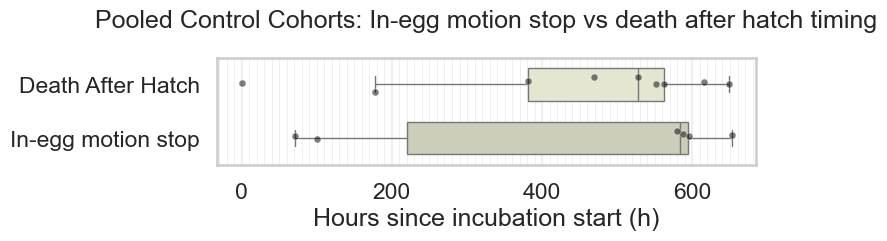

,event_group,n
0,Death After Hatch,9
1,In-egg motion stop,6


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/controls/plots/controls_motion_stop_timing_hatching_vs_in_egg.png


In [8]:
# Boxplot + stripplot overlay for death_after_hatch vs in-egg stop timing

print('Figure caption: Motion-stop timing comparison in pooled embryonated controls between two endpoint cohorts: death after hatch versus in-egg motion stop. X-axis is hours since incubation start (`dt_motion_stop_h`). Boxes summarize median/IQR with 1.5xIQR whiskers (fliers hidden), and jittered points show individual eggs from each endpoint cohort.')

plot_df = pd.concat(
    [
        hatching_df.assign(event_group="Death After Hatch"),
        in_egg_stop_df.assign(event_group="In-egg motion stop"),
    ],
    ignore_index=True,
)
plot_df = plot_df[["event_group", "dt_motion_stop_h"]].dropna().copy()

order = ["Death After Hatch", "In-egg motion stop"]
palette = {
    "Death After Hatch": "#e7e9ce",
    "In-egg motion stop": "#ced0b8",
}

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="event_group",
    order=order,
    palette=palette,
    showfliers=False,
    width=0.6,
    dodge=False,
    linewidth=1.0,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="dt_motion_stop_h",
    y="event_group",
    order=order,
    color="black",
    size=5,
    alpha=0.5,
    linewidth=0.5,
    edgecolor="white",
    jitter=0.15,
    ax=ax,
)

ax.set_xlabel("Hours since incubation start (h)")
ax.set_ylabel("")
ax.set_title("Pooled Control Cohorts: In-egg motion stop vs death after hatch timing", y=1.2)
ax.grid(axis="x", alpha=0.3)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

plt.tight_layout()
out_png = PLOTS_DIR / "controls_motion_stop_timing_hatching_vs_in_egg.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

plot_counts = (
    plot_df.groupby("event_group", observed=False)
    .size()
    .rename("n")
    .reset_index()
)
display(plot_counts)

plot_df.to_csv(TABLES_DIR / "controls_motion_stop_plot_data.csv", index=False)
print(f"Saved: {out_png.resolve()}")




<!-- Cell purpose: Introduce figure caption:. -->

Figure caption:
Timing of larval motion cessation in pooled embryonated control cohorts (`ctrl-1`, `ctrl-2`, `ctrl-3`). The x-axis reports `dt_motion_stop_h = t_motion_stop_h - t_start_h` (hours since incubation start). The y-axis separates endpoint cohorts: `In-egg motion stop` versus `Death After Hatch`. `Death After Hatch` includes eggs flagged `death_after_hatch` with non-missing stop timing; `In-egg motion stop` includes eggs with measured motion stop inside the egg, excluding `death_after_hatch`, and constrained to the 700 h footage window (`t_motion_stop_h <= 700`). Larvae that were still moving at end-of-footage (`t_motion_stop_h = NA` and `death_mode = NA`) are excluded because no stop-time event is observed. Boxplots show median (center line) and interquartile range (box), with whiskers extending to 1.5x IQR. Boxplot fliers are suppressed, while jittered points display all individual eggs (including values beyond whiskers). This plot compares when terminal motion cessation occurred relative to hatch status in the pooled control condition.


In [9]:
# Terminal phenotype counts in pooled controls

death_categories = ["apoptotic_like", "necrotic_like", "uncertain", "uncertein"]
rows = []
for mode in death_categories:
    n_mode = int((ctrl_df["death_mode"] == mode).sum())
    rows.append(
        {
            TERMINAL_PHENOTYPE_LABEL: DEATH_MODE_DISPLAY.get(mode, mode),
            "n": n_mode,
            "pct_of_pooled_controls": round(pct(n_mode, n_total_controls), 1),
        }
    )

death_phenotype_summary = (
    pd.DataFrame(rows)
    .groupby(TERMINAL_PHENOTYPE_LABEL, as_index=False, dropna=False)["n"]
    .sum()
)
death_phenotype_summary["pct_of_pooled_controls"] = death_phenotype_summary["n"].map(
    lambda x: round(pct(int(x), n_total_controls), 1)
)
display(death_phenotype_summary)

n_death_mode_na = int(ctrl_df["death_mode"].isna().sum())
na_mode_row = pd.DataFrame(
    [
        {
            TERMINAL_PHENOTYPE_LABEL: "na",
            "n": n_death_mode_na,
            "pct_of_pooled_controls": round(pct(n_death_mode_na, n_total_controls), 1),
        }
    ]
)
display(na_mode_row)

indeterminate_breakdown = (
    ctrl_df.loc[ctrl_df["death_mode"].isin(["uncertain", "uncertein"]), "flags"]
    .fillna("na")
    .value_counts(dropna=False)
    .rename_axis("flag_within_indeterminate_or_hatched")
    .reset_index(name="n")
)
if len(indeterminate_breakdown) > 0:
    indeterminate_breakdown["pct_within_indeterminate_or_hatched"] = (
        indeterminate_breakdown["n"] / indeterminate_breakdown["n"].sum() * 100
    ).round(1)

display(indeterminate_breakdown)

death_phenotype_summary.to_csv(TABLES_DIR / "controls_death_phenotype_summary.csv", index=False)
na_mode_row.to_csv(TABLES_DIR / "controls_death_mode_na_summary.csv", index=False)
indeterminate_breakdown.to_csv(TABLES_DIR / "controls_uncertain_breakdown_by_flag.csv", index=False)


,Terminal phenotype,n,pct_of_pooled_controls
0,Indeterminate/hatched,12,12.4
1,Lytic (necrosis-like),3,3.1
2,Vacuolated (apoptosis-like),0,0.0


,Terminal phenotype,n,pct_of_pooled_controls
0,na,82,84.5


,flag_within_indeterminate_or_hatched,n,pct_within_indeterminate_or_hatched
0,death_after_hatch,9,75.0
1,na,2,16.7
2,exit_egg,1,8.3
